# Makale Yeniden Üretimi: Caruana ve ark. (2015)

**Makale:** Caruana, R., Lou, Y., Gehrke, J., Koch, P., Sturm, M., & Elhadad, N. (2015).
*Intelligible Models for HealthCare: Predicting Pneumonia Risk and Hospital 30-day Readmission.* KDD '15, 1721–1730.

**Yeniden üreten:** Ahmet Batuhan Kaya (20269348005) · Açıklanabilir Yapay Zeka, 2026 Güz

**Seçenek 2 (Kıyaslama):** Lojistik regresyonun zayıf kaldığı bir durumu (doğrusallık varsayımı)
başka bir algoritmayla (GA²M) kıyaslıyoruz.

Makalenin iki iddiası:
1. GA²M (GAM + ikili etkileşimler) kara kutular kadar doğru olabilir.
2. Yorumlanabilirlik, verinin öğrettiği tehlikeli örüntüleri (ör. "astım riski azaltır") görünür kılar.

Makalenin verileri kamuya açık değil. Makalenin **ikinci görevini (30 günlük yeniden yatış)**,
kamuya açık bir veride yeniden üretiyoruz: ABD'deki 130 hastanenin diyabet hastası yatışları
(Strack ve ark., 2014; UCI Machine Learning Repository).

GA²M'nin bugünkü Python uygulaması: InterpretML kütüphanesindeki **EBM** (Explainable Boosting Machine),
Caruana'nın ekibi tarafından geliştirildi (Nori ve ark., 2019).

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from interpret.glassbox import ExplainableBoostingClassifier

warnings.filterwarnings("ignore")
RNG = np.random.default_rng(42)
SEKIL_KLASORU = "sekiller"
os.makedirs(SEKIL_KLASORU, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.width", 160)


def kaydet(ad):
    plt.tight_layout()
    plt.savefig(os.path.join(SEKIL_KLASORU, ad), dpi=150, bbox_inches="tight")
    plt.show()

## 1. Veri

101.766 hastane yatışı, 1999–2008. Hedef: hastanın taburcu olduktan sonraki **30 gün içinde**
yeniden yatması (`readmitted == "<30"`). Makaledeki readmission görevinin tanımıyla aynı.

Önemli bir ön işlem (Strack ve ark. gibi): Aynı hasta birden çok kez yatmış olabilir. Bölüm 6'daki
**bağımsızlık varsayımı** için her hastanın yalnızca **ilk** yatışını tutuyoruz.

In [2]:
VERI_URL = ("https://raw.githubusercontent.com/fairlearn/talks/main/"
            "2021_scipy_tutorial/data/diabetic_data.csv")


def veri_yukle():
    if os.path.exists("diabetic_data.csv"):
        return pd.read_csv("diabetic_data.csv", na_values="?")
    d = pd.read_csv(VERI_URL, na_values="?")
    d.to_csv("diabetic_data.csv", index=False)
    return d


ham = veri_yukle()
print("Ham veri:", ham.shape)
ham = ham.sort_values("encounter_id").drop_duplicates("patient_nbr", keep="first")
print("Hasta başına ilk yatış:", ham.shape)

Ham veri: (101766, 50)
Hasta başına ilk yatış: (71518, 50)


In [3]:
TABURCU = {
    1: "Ev", 6: "Ev + evde bakım", 8: "Ev + evde bakım",
    3: "Bakım evi", 4: "Bakım evi", 24: "Bakım evi",
    2: "Başka hastane", 5: "Başka hastane", 23: "Başka hastane", 27: "Başka hastane",
    28: "Başka hastane", 29: "Başka hastane", 30: "Başka hastane", 15: "Başka hastane",
    22: "Rehabilitasyon",
    7: "Kendi isteğiyle ayrıldı",
    11: "Vefat", 19: "Vefat", 20: "Vefat", 21: "Vefat",
    13: "Hospis (bakım evi)", 14: "Hospis (bakım evi)",
}
KABUL = {7: "Acil servis", 1: "Hekim sevki", 2: "Hekim sevki", 3: "Hekim sevki"}
KABUL_TURU = {1: "Acil", 2: "Ivedi", 3: "Planli"}


def tani_grubu(kod):
    """Strack ve ark. (2014) ICD-9 gruplaması."""
    if pd.isna(kod):
        return "Bilinmiyor"
    if str(kod).startswith(("V", "E")):
        return "Diğer"
    k = float(kod)
    if 390 <= k <= 459 or int(k) == 785:
        return "Dolaşım"
    if 460 <= k <= 519 or int(k) == 786:
        return "Solunum"
    if 520 <= k <= 579 or int(k) == 787:
        return "Sindirim"
    if int(k) == 250:
        return "Diyabet"
    if 800 <= k <= 999:
        return "Yaralanma"
    if 710 <= k <= 739:
        return "Kas-iskelet"
    if 580 <= k <= 629 or int(k) == 788:
        return "Ürogenital"
    if 140 <= k <= 239:
        return "Tümör"
    return "Diğer"


veri = pd.DataFrame({
    "yas": ham["age"].str.extract(r"\[(\d+)-")[0].astype(int) + 5,   # [70-80) -> 75
    "cinsiyet": ham["gender"].replace("Unknown/Invalid", "Kadın").map({"Female": "Kadın", "Male": "Erkek", "Kadın": "Kadın"}),
    "irk": ham["race"].fillna("Bilinmiyor"),
    "yatis_gunu": ham["time_in_hospital"],
    "lab_islem": ham["num_lab_procedures"],
    "islem": ham["num_procedures"],
    "ilac_sayisi": ham["num_medications"],
    "onceki_ayakta": ham["number_outpatient"],
    "onceki_acil": ham["number_emergency"],
    "onceki_yatis": ham["number_inpatient"],
    "tani_sayisi": ham["number_diagnoses"],
    "ana_tani": ham["diag_1"].map(tani_grubu),
    "A1C": ham["A1Cresult"].fillna("Ölçülmedi"),
    "glukoz": ham["max_glu_serum"].fillna("Ölçülmedi"),
    "insulin": ham["insulin"],
    "ilac_degisti": ham["change"].map({"Ch": "Evet", "No": "Hayır"}),
    "diyabet_ilaci": ham["diabetesMed"].map({"Yes": "Evet", "No": "Hayır"}),
    "taburcu": ham["discharge_disposition_id"].map(TABURCU).fillna("Diğer/bilinmiyor"),
    "kabul_kaynagi": ham["admission_source_id"].map(KABUL).fillna("Diğer"),
    "kabul_turu": ham["admission_type_id"].map(KABUL_TURU).fillna("Diğer"),
})
y = (ham["readmitted"] == "<30").astype(int).values
print(veri.shape, f"| 30 günde yeniden yatış oranı: %{100 * y.mean():.2f}  (makalede %8,91)")
print(pd.crosstab(veri["taburcu"], y, margins=True).rename(columns={0: "yatmadı", 1: "yattı"}))

(71518, 20) | 30 günde yeniden yatış oranı: %8.80  (makalede %8,91)
col_0                    yatmadı  yattı    All
taburcu                                       
Bakım evi                   8117   1233   9350
Başka hastane               2387    458   2845
Diğer/bilinmiyor            2978    302   3280
Ev                         41239   3078  44317
Ev + evde bakım             7566    796   8362
Hospis (bakım evi)           445     16    461
Kendi isteğiyle ayrıldı      370     39    409
Rehabilitasyon              1039    371   1410
Vefat                       1084      0   1084
All                        65225   6293  71518


## 2. Kıyaslama (makaledeki Tablo 2)

Makaledeki beş model:
- **Lojistik regresyon** (Bölüm 7): doğrusal, toplamsal.
- **GAM** (Bölüm 8): her öznitelik için bir eğri f(x), etkileşim yok. → EBM, `interactions=0`
- **GA²M**: GAM + en güçlü k ikili etkileşim f(xᵢ, xⱼ). → EBM, `interactions=10` (makaledeki pnömoni modeli gibi 10 çift)
- **Rastgele orman** ve **gradient boosting** (makalede LogitBoost): kara kutular.

Ölçüt: test verisinde AUC. Belirsizliği göstermek için 200 bootstrap ile %95 güven aralığı.

In [4]:
X_tr, X_te, y_tr, y_te = train_test_split(veri, y, test_size=0.3, random_state=0, stratify=y)

# Lojistik regresyon ve kara kutular için one-hot kodlama
X_oh = pd.get_dummies(veri, drop_first=True, dtype=float)
Xo_tr, Xo_te = X_oh.loc[X_tr.index], X_oh.loc[X_te.index]
ort, ss = Xo_tr.mean(), Xo_tr.std() + 1e-9

modeller = {}
modeller["Lojistik regresyon"] = LogisticRegression(max_iter=5000).fit((Xo_tr - ort) / ss, y_tr)
modeller["GAM (EBM, etkileşimsiz)"] = ExplainableBoostingClassifier(interactions=0, random_state=0, n_jobs=-1).fit(X_tr, y_tr)
modeller["GA²M (EBM, 10 etkileşim)"] = ExplainableBoostingClassifier(interactions=10, random_state=0, n_jobs=-1).fit(X_tr, y_tr)
modeller["Rastgele orman"] = RandomForestClassifier(n_estimators=400, min_samples_leaf=20, n_jobs=-1,
                                                    random_state=0).fit(Xo_tr, y_tr)
modeller["Gradient boosting"] = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05,
                                                               random_state=0).fit(Xo_tr, y_tr)


def tahmin(ad, X_ham, X_onehot):
    m = modeller[ad]
    if ad.startswith("Lojistik"):
        return m.predict_proba((X_onehot - ort) / ss)[:, 1]
    if "EBM" in ad:
        return m.predict_proba(X_ham)[:, 1]
    return m.predict_proba(X_onehot)[:, 1]


def bootstrap_ga(y_gercek, p, B=200):
    n = len(y_gercek)
    aucs = [roc_auc_score(y_gercek[i], p[i]) for i in (RNG.integers(0, n, n) for _ in range(B))]
    return np.percentile(aucs, [2.5, 97.5])


sonuc = []
for ad in modeller:
    p = tahmin(ad, X_te, Xo_te)
    alt, ust = bootstrap_ga(y_te, p)
    sonuc.append({"model": ad, "AUC": roc_auc_score(y_te, p), "GA alt": alt, "GA üst": ust})
sonuc = pd.DataFrame(sonuc).set_index("model").round(4)
print(sonuc)

                             AUC  GA alt  GA üst
model                                           
Lojistik regresyon        0.6443  0.6338  0.6581
GAM (EBM, etkileşimsiz)   0.6433  0.6288  0.6570
GA²M (EBM, 10 etkileşim)  0.6474  0.6346  0.6613
Rastgele orman            0.6506  0.6367  0.6642
Gradient boosting         0.6504  0.6355  0.6627


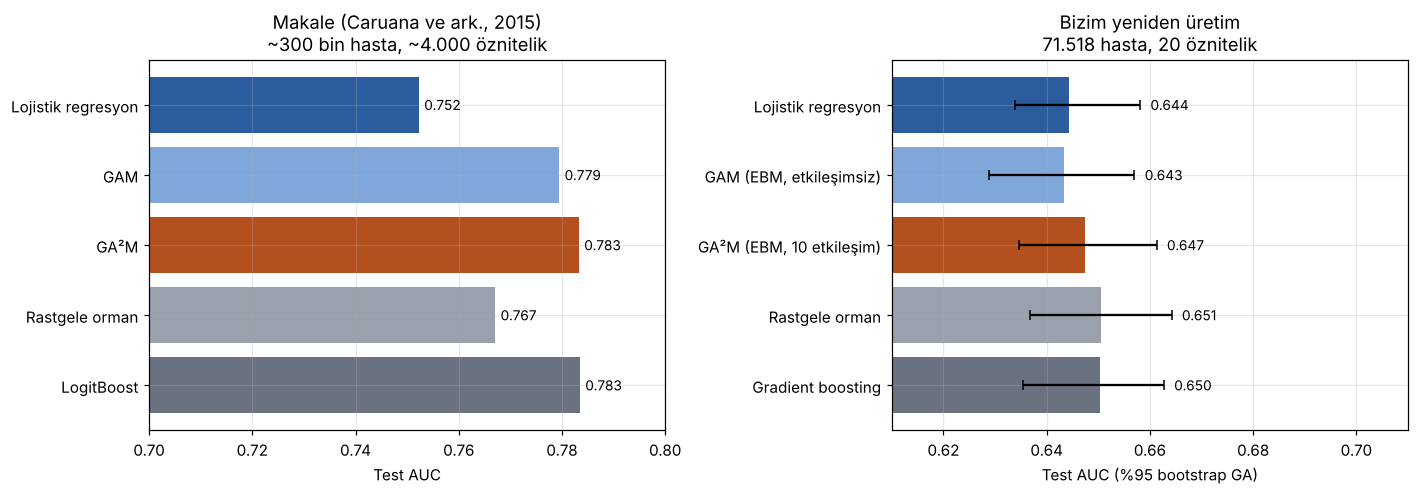

In [5]:
makale = pd.Series({"Lojistik regresyon": 0.7523, "GAM": 0.7795, "GA²M": 0.7833,
                    "Rastgele orman": 0.7671, "LogitBoost": 0.7835})
renk = ["#2B5C9E", "#7FA7D9", "#B4501E", "#9AA1AC", "#6A7180"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
axes[0].barh(makale.index[::-1], makale.values[::-1], color=renk[::-1])
axes[0].set(xlim=(0.70, 0.80), title="Makale (Caruana ve ark., 2015)\n~300 bin hasta, ~4.000 öznitelik", xlabel="Test AUC")
for i, v in enumerate(makale.values[::-1]):
    axes[0].text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=9)
axes[1].barh(sonuc.index[::-1], sonuc["AUC"].values[::-1], color=renk[::-1],
             xerr=[sonuc["AUC"].values[::-1] - sonuc["GA alt"].values[::-1],
                   sonuc["GA üst"].values[::-1] - sonuc["AUC"].values[::-1]], capsize=3)
lo = np.floor(sonuc["GA alt"].min() * 100) / 100 - 0.01
hasta_sayisi = f"{len(veri):,}".replace(",", ".")
axes[1].set(xlim=(lo, lo + 0.10), title=f"Bizim yeniden üretim\n{hasta_sayisi} hasta, {veri.shape[1]} öznitelik",
            xlabel="Test AUC (%95 bootstrap GA)")
for i, (v, u) in enumerate(zip(sonuc["AUC"].values[::-1], sonuc["GA üst"].values[::-1])):
    axes[1].text(u + 0.002, i, f"{v:.3f}", va="center", fontsize=9)
kaydet("01_auc_kiyas.png")

# Yorum: İki tabloda da aynı örüntü aranıyor: GAM/GA²M, lojistik regresyonu geçiyor mu ve
# kara kutulara yetişiyor mu? Mutlak AUC'ler farklı (bizim veri çok daha küçük ve fakir).

## 3. Şekil fonksiyonları: doğrusallık nerede çöküyor?

GAM/GA²M'nin gücü: her özniteliğin etkisini bir eğri olarak çizebiliriz (Bölüm 8).
Lojistik regresyon ise her sayısal özniteliğe tek bir eğim verir (Bölüm 7).
Aynı grafikte ikisini karşılaştırıyoruz (log-odds ölçeği, ortalama etrafında merkezlenmiş).

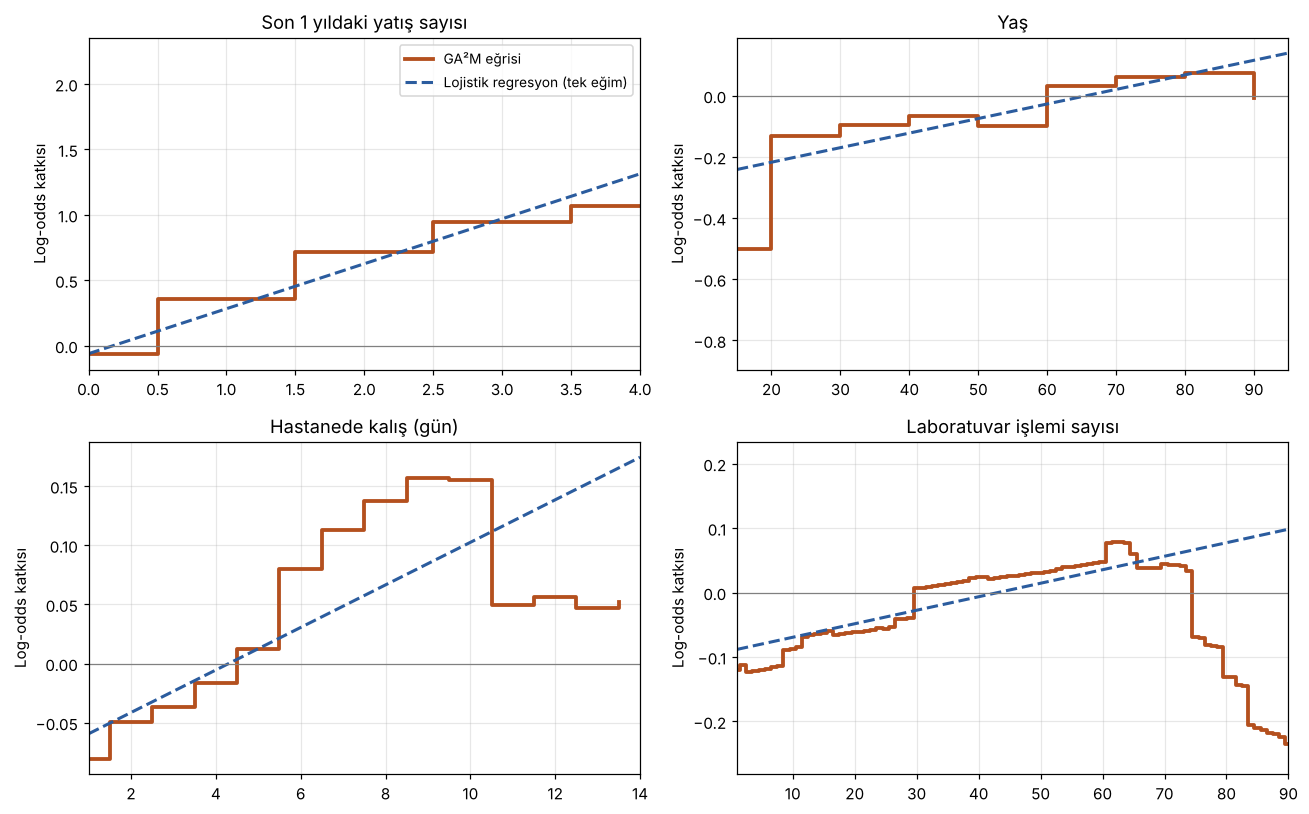

In [6]:
ga2m = modeller["GA²M (EBM, 10 etkileşim)"]
lr = modeller["Lojistik regresyon"]
global_ac = ga2m.explain_global()
lr_beta = pd.Series(lr.coef_[0], index=X_oh.columns) / ss      # standartlaştırılmış -> ham birim


def ebm_sekil(ad):
    d = global_ac.data(ga2m.term_names_.index(ad))
    return np.asarray(d["names"]), np.asarray(d["scores"])


secilen = [("onceki_yatis", "Son 1 yıldaki yatış sayısı"), ("yas", "Yaş"),
           ("yatis_gunu", "Hastanede kalış (gün)"), ("lab_islem", "Laboratuvar işlemi sayısı")]
fig, axes = plt.subplots(2, 2, figsize=(12, 7.5))
for ax, (ad, baslik) in zip(axes.flat, secilen):
    kenar, skor = ebm_sekil(ad)
    ax.step(kenar[:-1] if len(kenar) == len(skor) + 1 else kenar, skor, where="post",
            color="#B4501E", lw=2.5, label="GA²M eğrisi")
    x = np.linspace(veri[ad].quantile(0.005), veri[ad].quantile(0.995), 100)
    ax.plot(x, lr_beta[ad] * (x - X_tr[ad].mean()), color="#2B5C9E", lw=2, ls="--",
            label="Lojistik regresyon (tek eğim)")
    ax.set(title=baslik, ylabel="Log-odds katkısı", xlim=(x.min(), x.max()))
    ax.axhline(0, color="gray", lw=0.8)
axes[0, 0].legend(fontsize=9)
kaydet("02_sekil_fonksiyonlari.png")

## 4. Tehlikeli örüntü: "astım riski azaltır"ın bu verideki karşılığı

Makalede astımlı zatürre hastaları daha düşük riskli görünüyordu, çünkü doğrudan yoğun bakıma
alınıyorlardı. Model veriyi doğru öğrenmişti ama bu bilgiyle karar verilirse hastalar zarar görürdü.

Bizim veride en önemli öznitelik ne? Ve öğrendiği şey sağlık açısından ne anlama geliyor?

In [7]:
onem = pd.Series(ga2m.term_importances(), index=ga2m.term_names_).sort_values(ascending=False)
print(onem.head(12).round(4))

taburcu                    0.3009
onceki_yatis               0.1188
ana_tani                   0.0743
yas                        0.0698
yatis_gunu                 0.0586
lab_islem                  0.0476
diyabet_ilaci              0.0432
lab_islem & ilac_sayisi    0.0348
tani_sayisi & taburcu      0.0326
tani_sayisi                0.0312
insulin                    0.0266
taburcu & kabul_turu       0.0211
dtype: float64


                         katkı      n   oran
Vefat                   -4.703   1084  0.000
Hospis (bakım evi)      -0.780    461  0.035
Ev                      -0.116  44317  0.069
Ev + evde bakım          0.138   8362  0.095
Diğer/bilinmiyor         0.234   3280  0.092
Kendi isteğiyle ayrıldı  0.455    409  0.095
Bakım evi                0.500   9350  0.132
Başka hastane            0.755   2845  0.161
Rehabilitasyon           1.291   1410  0.263


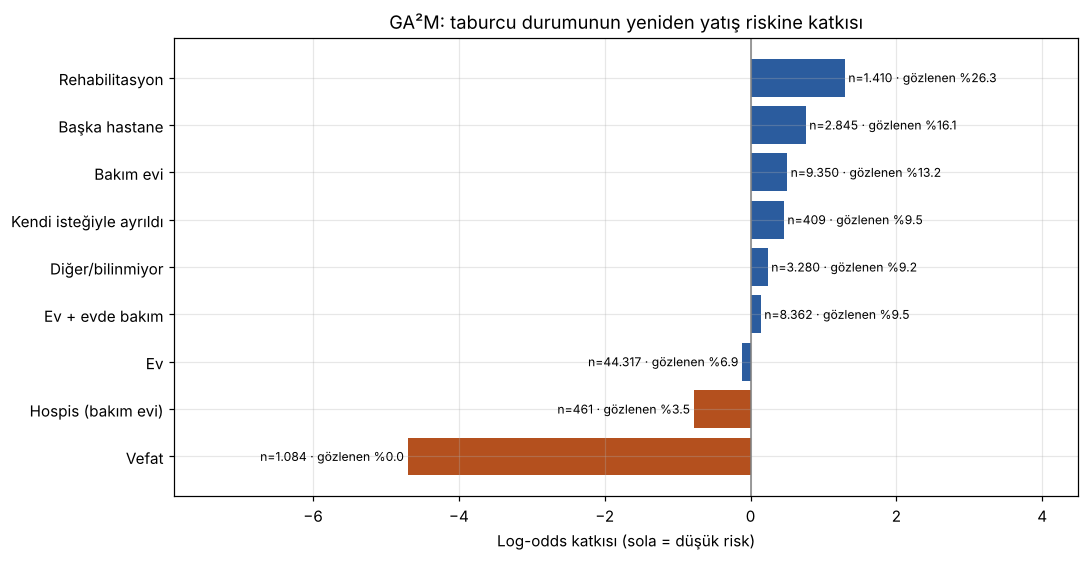

Lojistik regresyon, taburcu=Vefat katsayısı (log-odds): -6.94  → odds oranı 0.0010


In [8]:
kat, skor = ebm_sekil("taburcu")
taburcu_df = pd.DataFrame({"katkı": skor}, index=kat)
ozet = veri.assign(y=y).groupby("taburcu")["y"].agg(n="size", oran="mean")
taburcu_df = taburcu_df.join(ozet).sort_values("katkı")
print(taburcu_df.round(3))

renkler = ["#B4501E" if k in ("Vefat", "Hospis (bakım evi)") else "#2B5C9E" for k in taburcu_df.index]
fig, ax = plt.subplots(figsize=(10, 5.2))
ax.barh(taburcu_df.index, taburcu_df["katkı"], color=renkler)
for i, (k, r) in enumerate(taburcu_df.iterrows()):
    ax.text(r["katkı"] + (0.05 if r["katkı"] >= 0 else -0.05), i,
            f"n={int(r['n']):,}".replace(",", ".") + f" · gözlenen %{100 * r['oran']:.1f}",
            va="center", ha="left" if r["katkı"] >= 0 else "right", fontsize=8)
ax.axvline(0, color="gray", lw=1)
ax.set(title="GA²M: taburcu durumunun yeniden yatış riskine katkısı", xlabel="Log-odds katkısı (sola = düşük risk)")
ax.set_xlim(taburcu_df["katkı"].min() - 3.2, taburcu_df["katkı"].max() + 3.2)
kaydet("03_taburcu_tehlikeli_oruntu.png")

# Yorum: Model "vefat eden hastanın yeniden yatma riski çok düşük" diyor. Doğru! Ölen hasta tekrar yatamaz.
# Ama bu modeli "taburculuk sonrası kimi arayalım?" kararında kullanan bir hastane, hospise giden en ağır
# hastaları düşük riskli sayardı. Model veriyi açıklıyor, dünyayı değil: astım örneğinin birebir benzeri.
# Ayrıca bu, bir tür hedef sızıntısı (leakage): taburcu anında "vefat" bilgisi, sonucun kendisini taşıyor.

# Bölüm 7 ile bağlantı: "Vefat" kategorisinde HİÇ yeniden yatış yok (0/1084). Bu, tam ayrışmanın ta kendisi:
# en çok olabilirlik katsayıyı sonsuza itmek ister. EBM'nin katkısı −4,7'de kalıyor, çünkü boosting
# küçük adımlarla ve sınırlı sayıda turla öğreniyor (örtük bir düzenlileştirme).
# Lojistik regresyonumuz da ceza (L2, C=1) içerdiği için katsayısı sonlu kalıyor:
print(f"Lojistik regresyon, taburcu=Vefat katsayısı (log-odds): {lr_beta['taburcu_Vefat']:.2f}  "
      f"→ odds oranı {np.exp(lr_beta['taburcu_Vefat']):.4f}")

In [9]:
# Makalenin önerisi: terimi modelden çıkar ya da uzman bilgisiyle düzelt.
# Strack ve ark. (2014) da vefat ve hospis hastalarını analizden çıkarıyor. Biz de öyle yapalım.
maske_tr = ~X_tr["taburcu"].isin(["Vefat", "Hospis (bakım evi)"]).values
maske_te = ~X_te["taburcu"].isin(["Vefat", "Hospis (bakım evi)"]).values
ga2m_d = ExplainableBoostingClassifier(interactions=10, random_state=0, n_jobs=-1).fit(X_tr[maske_tr], y_tr[maske_tr])
p_eski = ga2m.predict_proba(X_te[maske_te])[:, 1]
p_yeni = ga2m_d.predict_proba(X_te[maske_te])[:, 1]
print(f"Vefat/hospis çıkarılmış test kümesinde AUC: eski model {roc_auc_score(y_te[maske_te], p_eski):.4f} · "
      f"düzeltilmiş model {roc_auc_score(y_te[maske_te], p_yeni):.4f}")
p_hospis = ga2m.predict_proba(X_te[X_te["taburcu"] == "Hospis (bakım evi)"])[:, 1]
print(f"Eski modelin hospise taburcu edilen hastalara verdiği ortalama risk: %{100 * p_hospis.mean():.1f} "
      f"(genel ortalama %{100 * y.mean():.1f})")

Vefat/hospis çıkarılmış test kümesinde AUC: eski model 0.6402 · düzeltilmiş model 0.6408
Eski modelin hospise taburcu edilen hastalara verdiği ortalama risk: %4.3 (genel ortalama %8.8)


## 5. GA²M'nin farkı: ikili etkileşimler

GA²M, GAM'e en güçlü k ikili etkileşimi ekler (makalede FAST algoritmasıyla seçiliyor).
Bölüm 8'deki "sıcaklık × iş günü" etkileşiminin otomatik bulunmuş hâli.

GA²M'nin seçtiği etkileşimler (önem sırasıyla):
lab_islem & ilac_sayisi    0.0348
tani_sayisi & taburcu      0.0326
taburcu & kabul_turu       0.0211
cinsiyet & tani_sayisi     0.0200
yas & taburcu              0.0186
lab_islem & taburcu        0.0178
ilac_sayisi & ana_tani     0.0157
ilac_sayisi & A1C          0.0124
yas & onceki_yatis         0.0075
onceki_yatis & ana_tani    0.0055
dtype: float64


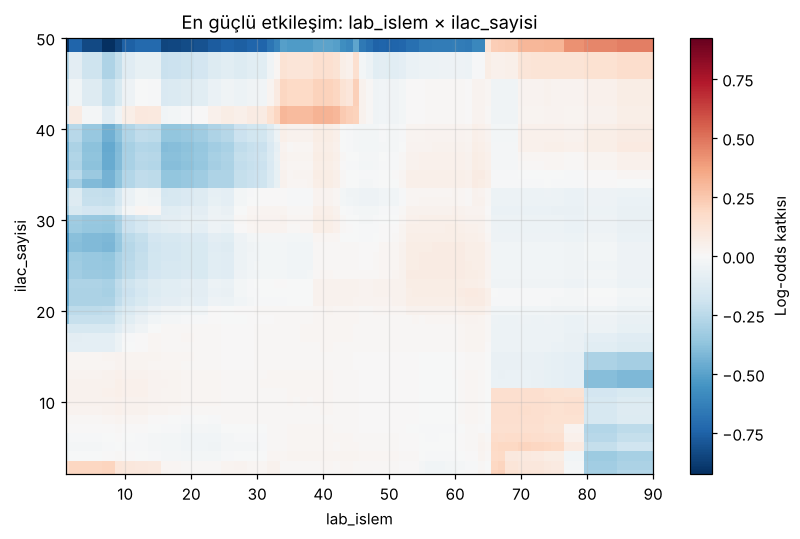

In [10]:
etkilesimler = [t for t in onem.index if " & " in t]
print("GA²M'nin seçtiği etkileşimler (önem sırasıyla):")
print(onem[etkilesimler].round(4))

en_guclu = etkilesimler[0]
d = global_ac.data(ga2m.term_names_.index(en_guclu))
skor2 = np.asarray(d["scores"])
sol, sag = en_guclu.split(" & ")
kx, ky = np.asarray(d["left_names"], dtype=float), np.asarray(d["right_names"], dtype=float)
fig, ax = plt.subplots(figsize=(7.5, 5))
sinir = np.abs(skor2).max()
im = ax.pcolormesh(kx, ky, skor2.T, cmap="RdBu_r", vmin=-sinir, vmax=sinir, shading="flat")
ax.set(xlim=(veri[sol].quantile(0.005), veri[sol].quantile(0.995)),
       ylim=(veri[sag].quantile(0.005), veri[sag].quantile(0.995)),
       title=f"En güçlü etkileşim: {sol} × {sag}", xlabel=sol, ylabel=sag)
fig.colorbar(im, ax=ax, label="Log-odds katkısı")
kaydet("04_etkilesim.png")

## 6. Sonuç

1. **Doğruluk:** Bu veride yorumlanabilir modeller (lojistik regresyon, GAM, GA²M) kara kutularla
   aynı düzeyde. Makalenin "yorumlanabilir model yeterince iyi" iddiası destekleniyor.
   Makaleden farklı olarak GAM/GA²M lojistik regresyonu belirgin biçimde geçemiyor; olası neden
   verimizin çok daha küçük ve öznitelik açısından fakir olması (20'ye karşı ~4.000).
2. **Şekiller:** Önceki yatış sayısının etkisi doğrusal değil; GA²M bunu yakalıyor, lojistik
   regresyon tek bir eğimle özetlemek zorunda.
3. **Tehlikeli örüntü:** En önemli öznitelik taburcu durumu. Model, vefat eden ve hospise giden
   hastaları "düşük risk" olarak öğreniyor: makaledeki astım bulgusunun bu verideki karşılığı.
   Yorumlanabilir model sayesinde bunu gördük ve düzelttik.

**Sınırlılıklar:** Farklı veri (diyabet hastaları, 1999–2008), çok daha az öznitelik, tek bir
eğitim/test ayrımı. EBM, makaledeki GA²M'nin birebir aynısı değil, aynı fikrin güncel uygulaması.